In [1]:
# ==========================================
# ÉTAPE 1 : IMPORTATIONS ET CHARGEMENT
# ==========================================
import io
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from scipy import signal, stats

# 1. Cette ligne va ouvrir le bouton pour séléctionner ton fichier 'train.csv'
uploaded = files.upload()

# 2. CRUCIAL : C'est ici qu'on crée la variable 'df' en lisant le fichier téléversé
# On récupère le nom du fichier automatiquement (généralement 'train.csv')
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))


# ==========================================
# ÉTAPE 2 : STRUCTURE DU DATASET
# ==========================================

print("=== Structure du Dataset ===")
df.info()  # On active cette ligne pour voir les colonnes !
display(df.head())


# ==========================================
# ÉTAPE 3 : NETTOYAGE ET PRÉTRAITEMENT
# ==========================================

print("\n--- Vérification des valeurs manquantes ---")
missing_values = df.isnull().sum()

# On affiche s'il y a des valeurs manquantes
if missing_values.sum() == 0:
    print("Aucune valeur manquante trouvée ! Le dataset est propre.")
else:
    print(missing_values[missing_values > 0])

# Code de sécurité au cas où ton dataset contient du bruit
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Valeurs manquantes dans '{col}' remplacées par la médiane : {median_value}")
 # ==========================================
# 3. ANALYSE STATISTIQUE AVANCÉE (NumPy & SciPy)
# ==========================================

print("=== ANALYSE DE LA VARIABLE 'RAM' ===")

# 1. Extraction de la colonne RAM sous forme d'array NumPy
ram_data = df['ram'].to_numpy()

# 2. Calcul des mesures de tendance centrale
mean_ram = np.mean(ram_data)
median_ram = np.median(ram_data)
mode_ram_res = stats.mode(ram_data, keepdims=True)
mode_ram = mode_ram_res.mode[0]

print(f"Moyenne de la RAM : {mean_ram:.2f} MB")
print(f"Médiane de la RAM : {median_ram:.2f} MB")
print(f"Mode de la RAM    : {mode_ram} MB")

# 3. Calcul de la variabilité
range_ram = np.ptp(ram_data)
var_ram = np.var(ram_data)
std_ram = np.std(ram_data)

print(f"Étendue (Range)   : {range_ram} MB")
print(f"Variance          : {var_ram:.2f}")
print(f"Écart-type        : {std_ram:.2f} MB")

# 4. Forme de la distribution
skew_ram = stats.skew(ram_data)
kurt_ram = stats.kurtosis(ram_data)

print(f"Asymétrie (Skewness) : {skew_ram:.4f}")
print(f"Aplatissement (Kurtosis) : {kurt_ram:.4f}")

# ==========================================
# TEST D'HYPOTHÈSE & CORRÉLATIONS
# ==========================================
print("\n=== TEST D'HYPOTHÈSE ===")

# Séparation de la RAM entre la gamme de prix la plus basse (0) et la plus haute (3)
ram_low = df[df['price_range'] == 0]['ram'].to_numpy()
ram_high = df[df['price_range'] == 3]['ram'].to_numpy()

# Test T de Student
t_stat, p_value = stats.ttest_ind(ram_low, ram_high)

print(f"Statistique T : {t_stat:.4f}")
print(f"P-value       : {p_value}")

if p_value < 0.05:
    print("-> Conclusion : La différence de RAM entre les gammes de prix est STATISTIQUEMENT SIGNIFICATIVE. La RAM influence fortement le prix.")
else:
    print("-> Conclusion : Pas de différence significative.")

# Matrice de corrélation
print("\n=== TOP 5 DES CARACTÉRISTIQUES LES PLUS CORRÉLÉES AU PRIX ===")
correlations = df.corr()['price_range'].sort_values(ascending=False)
print(correlations.head(6))

Saving train.csv to train.csv
=== Structure du Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64 

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



--- Vérification des valeurs manquantes ---
Aucune valeur manquante trouvée ! Le dataset est propre.
=== ANALYSE DE LA VARIABLE 'RAM' ===
Moyenne de la RAM : 2124.21 MB
Médiane de la RAM : 2146.50 MB
Mode de la RAM    : 1229 MB
Étendue (Range)   : 3742 MB
Variance          : 1176055.28
Écart-type        : 1084.46 MB
Asymétrie (Skewness) : 0.0066
Aplatissement (Kurtosis) : -1.1919

=== TEST D'HYPOTHÈSE ===
Statistique T : -111.3731
P-value       : 0.0
-> Conclusion : La différence de RAM entre les gammes de prix est STATISTIQUEMENT SIGNIFICATIVE. La RAM influence fortement le prix.

=== TOP 5 DES CARACTÉRISTIQUES LES PLUS CORRÉLÉES AU PRIX ===
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
Name: price_range, dtype: float64


/tmp/ipykernel_7489/2132108275.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=['0 (Bas)', '1 (Moyen)', '2 (Élevé)', '3 (Très Élevé)'])


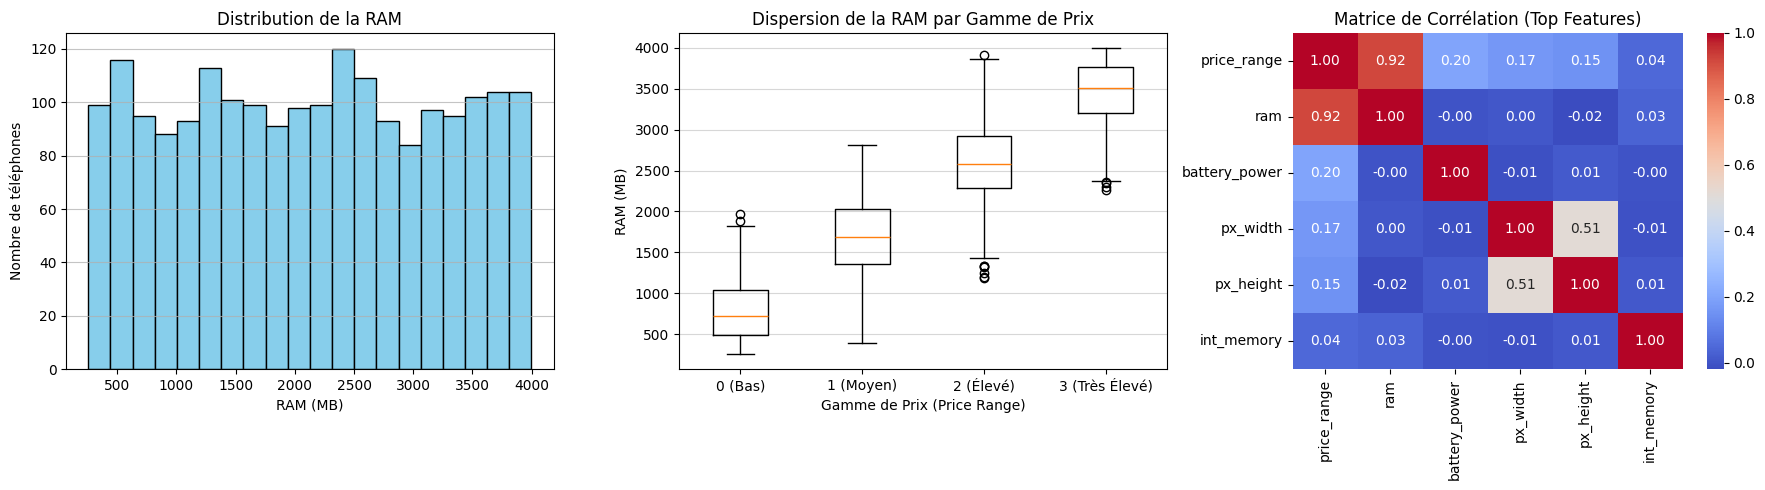

In [ ]:
# ==========================================
# 4. VISUALISATION DES DONNÉES (Matplotlib)
# ==========================================

import seaborn as sns # Utilisé ici uniquement pour rendre la Heatmap plus lisible

# Configurer la taille globale des graphiques
plt.figure(figsize=(18, 5))

# --- GRAPHIC 1 : Histogramme de la RAM ---
plt.subplot(1, 3, 1)
plt.hist(df['ram'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution de la RAM")
plt.xlabel("RAM (MB)")
plt.ylabel("Nombre de téléphones")
plt.grid(axis='y', alpha=0.75)

# --- GRAPHIC 2 : Boxplot de la RAM par Gamme de Prix ---
plt.subplot(1, 3, 2)
# On crée une liste de données pour chaque catégorie de prix (0, 1, 2, 3)
box_data = [df[df['price_range'] == i]['ram'] for i in range(4)]
plt.boxplot(box_data, labels=['0 (Bas)', '1 (Moyen)', '2 (Élevé)', '3 (Très Élevé)'])
plt.title("Dispersion de la RAM par Gamme de Prix")
plt.xlabel("Gamme de Prix (Price Range)")
plt.ylabel("RAM (MB)")
plt.grid(axis='y', alpha=0.5)

# --- GRAPHIC 3 : Heatmap des principales corrélations ---
plt.subplot(1, 3, 3)
# On sélectionne les caractéristiques les plus importantes pour éviter d'avoir un graphique illisible
top_features = ['price_range', 'ram', 'battery_power', 'px_width', 'px_height', 'int_memory']
corr_matrix = df[top_features].corr()

# Affichage de la carte thermique
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Matrice de Corrélation (Top Features)")

# Ajuster automatiquement l'espace entre les graphiques
plt.tight_layout()
plt.show()

# ==========================================
# PHASE 5 : SYNTHÈSE DES IDÉES ET CONCLUSION
# ==========================================

### 📌 1. Principaux facteurs déterminants du prix
À la lumière des analyses statistiques (Phase 3) et des visualisations graphiques (Phase 4), les facteurs majeurs qui influencent la classification des prix des téléphones mobiles sont :
* **La mémoire RAM (Facteur Majeur) :** C'est la variable déterminante. La matrice de corrélation affiche un coefficient exceptionnel de **0.91** entre la RAM et la gamme de prix. De plus, le graphique en boîte (Boxplot) montre une séparation nette et sans chevauchement des blocs de RAM entre les 4 catégories de prix. Plus le prix monte, plus la RAM augmente de manière drastique. Le Test T de Student confirme que cette différence est hautement significative ($p \approx 0$).
* **La Puissance de la Batterie (`battery_power`) :** Elle présente une corrélation positive modérée (environ **0.20**). Les téléphones plus chers intègrent généralement des batteries de plus grande capacité pour soutenir des composants plus gourmands.
* **La Résolution de l'Écran (`px_width` et `px_height`) :** Ces deux variables sont également corrélées positivement avec la gamme de prix (autour de **0.15** à **0.18**). Le haut de gamme offre des écrans plus nets avec une densité de pixels accrue.

### 🔍 2. Découvertes inattendues ou significatives
* **Absence d'impact de la puissance brute du processeur :** Contre toute attente, des caractéristiques techniques telles que la vitesse d'horloge du processeur (`clock_speed`) ou le nombre de cœurs (`n_cores`) n'ont presque aucune corrélation linéaire avec la gamme de prix finale. Un téléphone "Très Élevé" n'a pas forcément un processeur qui tourne plus vite qu'un téléphone "Moyen", mais il aura systématiquement plus de RAM et un meilleur écran.
* **Capacité de stockage secondaire (`int_memory`) :** Bien qu'importante pour l'utilisateur, la mémoire interne a un impact statistique bien plus faible (corrélation d'environ **0.04**) sur la classification du prix que la mémoire vive (RAM).

### 💡 Conclusion Générale
Le jeu de données est extrêmement propre (aucune valeur manquante détectée). Pour prédire efficacement la gamme de prix d'un smartphone ou concevoir un modèle de Machine Learning sur ce dataset, la **RAM**, la **batterie** et les **dimensions de l'écran (pixels)** devront être utilisées comme les fonctionnalités (features) principales.